<div align="center">
    <img src="describ.jpeg"
         alt="Multimodal Phishing Detection"
         width="100%"
         style="height: 500px; object-fit: cover;">
</div>

# Data Overview

## About Dataset

This dataset focuses on comprehensive multimodal benchmarking for phishing website detection by combining structured URL-based features, lexical attributes, and DNS/network properties. It enables researchers, security engineers, and data scientists to explore threat patterns and train machine learning classifiers for intelligent web security systems.

## Column Description

| Column Name | Description |
| :--- | :--- |
| **url** | The target website uniform resource locator |
| **entropy** | Measure of randomness in the URL characters |
| **url_length** | Total character length of the URL string |
| **www** | Binary indicator for the presence of 'www' in the URL |
| **io** | Input/Output or protocol specific lexical indicator |
| **digits** | Number of numeric digits present in the URL |
| **n_subdomain** | Count of subdomains contained within the URL structure |
| **th_dom** | Threshold or target domain component analysis |
| **dom_num** | Numeric composition or representation within the domain |
| **dots** | Count of dot (.) characters in the URL |
| **hyphen** | Count of hyphen (-) characters in the URL |
| **at** | Presence or count of '@' symbols in the URL |
| **prefix_suffix** | Indicator of hyphen usage or prefix/suffix patterns in domain |
| **question** | Presence or count of question mark (?) query parameters |
| **equal** | Presence or count of equal (=) sign parameters |
| **domain_age** | Age of the registered domain name |
| **is_resolvat** | DNS resolution status flag for the domain |
| **num_ips** | Number of IP addresses resolved for the domain |
| **ttl** | Time To Live value for DNS records |
| **name_server** | Associated name server information |
| **label** | Target classification label (e.g., legitimate vs phishing) |

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Import library
</div>

In [3]:
# ================== Data & Math ==================
import pandas as pd
import numpy as np
import math

# ================== Visualization ==================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Function_To_Using
</div>

In [4]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [5]:
def plot_barplot(df, column, target):
  sns.set_style('whitegrid')
  plt.figure(figsize=(10, 5))
  total = len(df)
  ax = sns.countplot(data=df, x=column, hue=target, palette='Set2')
  plt.title(f'Bar Plot of {column} by {target}', fontsize=14, fontweight='bold')
  plt.xlabel(column, fontsize=12, fontweight='bold')
  plt.ylabel('Count', fontsize=12, fontweight='bold')

  for p in ax.patches:
    height = p.get_height()
    if height > 0:
      percentage = (height / total) * 100
      ax.annotate(
          f'{percentage:.1f}%',
          (p.get_x() + p.get_width() / 2.0, height),
          ha='center',
          va='bottom',
          fontsize=9,
          fontweight='bold',
          color='black',
      )

  plt.xticks(rotation=45)
  plt.legend(title=target)
  plt.show()

In [6]:

def plot_histogram(df, column, target):
  sns.set_style('whitegrid')
  plt.figure(figsize=(9, 5))
  ax = sns.histplot(
      data=df, x=column, hue=target, multiple='stack', kde=True, palette='viridis'
  )

  plt.title(
      f'Histogram & Distribution of {column} by {target}',
      fontsize=14,
      fontweight='bold',
  )
  plt.xlabel(column, fontsize=12, fontweight='bold')
  plt.ylabel('Count', fontsize=12, fontweight='bold')

  plt.show()

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    Exploratory Data
</div>

In [13]:
file_path = r"E:\Depi\Phishing and Legitimate Websites\Phishing dataset\Phishing dataset\url\merged_features_final.xlsx"
df = pd.read_excel(file_path)
df.head()

,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
0,https://manua.ls,3.500000,16,0,0.000000,0,8,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate
1,https://t.co/r77VHQx9lP,4.023137,23,0,0.130435,0,4,1,1,0,0.0,0,0,0,5745.0,1.0,1.0,300.0,8.0,phishing
2,https://sites.google.com/view/attyahoo-plus-la...,4.145908,58,0,0.000000,1,16,0,2,3,0.0,0,0,0,10351.0,1.0,6.0,300.0,4.0,phishing
3,https://bit.ly/48c5385,3.845351,22,0,0.272727,0,6,0,1,0,0.0,0,0,0,6453.0,1.0,2.0,300.0,8.0,phishing
4,https://strato.de,3.381580,17,0,0.000000,0,9,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate


In [14]:
df.tail()

,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
59995,https://q-r.to/bfJbhR,3.748995,21,0,0.000000,0,6,1,1,1,0.000000,1,0,0,5100.0,1.0,4.0,60.0,4.0,phishing
59996,https://hometrade-nomura.scd6753.com/?login=kj...,5.215636,68,0,0.102941,1,28,1,2,1,0.142857,0,1,1,1416.0,1.0,2.0,300.0,2.0,phishing
59997,https://nimbusweb.me,3.721928,20,0,0.000000,0,12,0,1,0,0.000000,0,0,0,-1.0,1.0,4.0,60.0,4.0,legitimate
59998,https://mhrs.gov.tr,3.471354,19,0,0.000000,0,11,1,2,0,0.000000,0,0,0,5731.0,1.0,1.0,3600.0,4.0,legitimate
59999,https://docs.google.com/presentation/d/e/2PACX...,5.583470,190,0,0.073684,1,15,0,3,3,0.000000,0,1,4,10352.0,1.0,6.0,300.0,4.0,phishing


In [15]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,url,str,"[https://manua.ls, https://t.co/r77VHQx9lP, ht...",60000,0,0.000000,0
1,entropy,float64,"[3.939470994001288, 4.152391277629867, 4.05595...",14054,0,0.000000,0
2,url_length,int64,"[22, 21, 23, 20, 19, 18, 17, 24, 175, 16]",454,0,0.000000,0
3,num_www,int64,"[0, 1, 2, 3]",4,0,0.000000,0
4,ratio_digits_url,float64,"[0.0, 0.0454545454545454, 0.0909090909090909, ...",2081,0,0.000000,0
5,num_subdomains,int64,"[0, 1, 2, 3, 4, 6, 5, 7]",8,0,0.000000,0
6,length_hostname,int64,"[15, 6, 11, 12, 7, 13, 10, 8, 14, 16]",79,0,0.000000,0
7,random_domain,int64,"[0, 1]",2,0,0.000000,0
8,num_dots,int64,"[1, 2, 3, 4, 5, 6, 13, 7, 10, 8]",18,0,0.000000,0
9,num_hyphens,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10]",28,0,0.000000,0


In [16]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
entropy,60000.000000,4.072082,0.563020,2.353338,3.719295,3.936260,4.222208,6.032729
url_length,60000.000000,44.119367,117.729571,12.000000,21.000000,24.000000,41.000000,25523.000000
num_www,60000.000000,0.097650,0.298746,0.000000,0.000000,0.000000,0.000000,3.000000
ratio_digits_url,60000.000000,0.045301,0.084466,0.000000,0.000000,0.000000,0.067797,0.826087
num_subdomains,60000.000000,0.481783,0.576923,0.000000,0.000000,0.000000,1.000000,7.000000
length_hostname,60000.000000,16.661200,10.369705,4.000000,10.000000,15.000000,20.000000,100.000000
random_domain,60000.000000,0.148483,0.355581,0.000000,0.000000,0.000000,0.000000,1.000000
num_dots,60000.000000,1.669483,0.975325,1.000000,1.000000,2.000000,2.000000,23.000000
num_hyphens,60000.000000,0.473500,1.102173,0.000000,0.000000,0.000000,1.000000,50.000000
ratio_digits_host,60000.000000,0.033072,0.103449,0.000000,0.000000,0.000000,0.000000,0.800000


In [21]:
print("Target Variable counts:")
df['label'].value_counts()

Target Variable counts:


label
phishing      31641
legitimate    28359
Name: count, dtype: int64

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 26px;
    font-weight: bold;
">
    EDA
</div>

<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 16px;
    font-weight: bold;
">
    Target Coulm
</div>

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\833991006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='Set2')


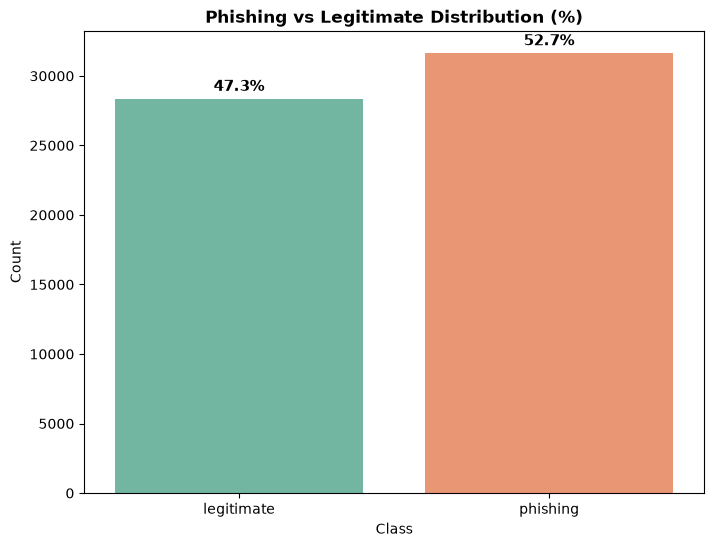

In [25]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phishing vs Legitimate Distribution (%)', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Count', fontsize=10)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{(height / total) * 100:.1f}%'
        ax.annotate(percentage, 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', 
                    xytext=(0, 3), textcoords='offset points')

plt.show()

**Insight / Observation:**
* The dataset is **well-balanced**, with approximately 47.3% legitimate websites and 52.7% phishing websites. 
* This balance is great for our model because we don't need to worry about class imbalance techniques (like SMOTE), and the classifier will learn fairly from both classes without any bias.


<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 16px;
    font-weight: bold;
">
    Numircal Coulm
</div>

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\2833421812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='entropy', palette='Set2')


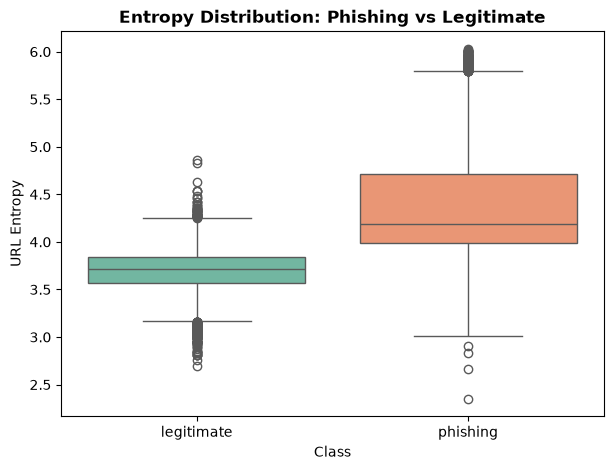

In [26]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='label', y='entropy', palette='Set2')
plt.title('Entropy Distribution: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('URL Entropy', fontsize=10)
plt.show()

**Insight / Observation:**
* From the boxplot, we can see that phishing URLs have a higher median entropy than legitimate ones, which proves that malicious links tend to be more random.


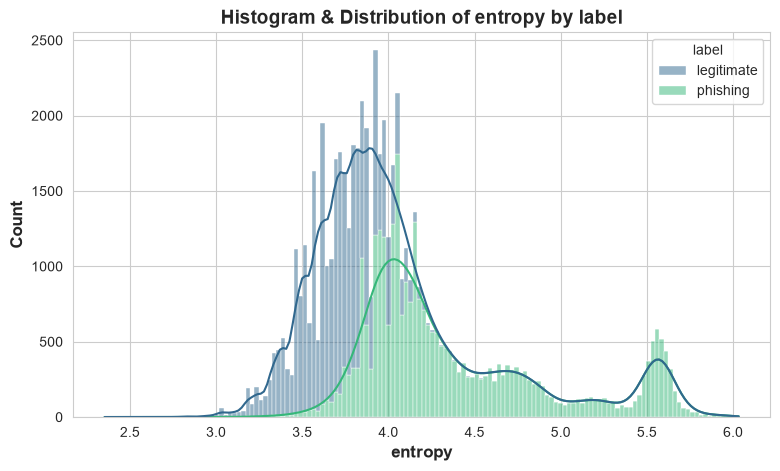

In [28]:
plot_histogram(df, column='entropy', target='label')

**Insight / Observation:**
* The histogram shows that legitimate URLs cluster together at lower entropy values because they have clean, structured names, while phishing URLs spread out towards higher values due to their randomized characters

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\3646221608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='url_length', palette='Set2')


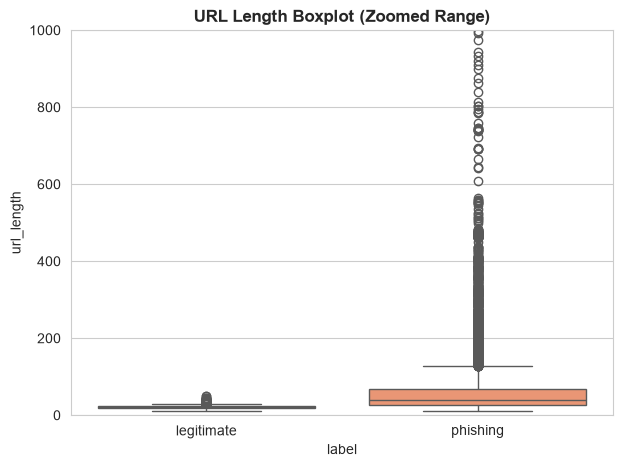

In [35]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='label', y='url_length', palette='Set2')
plt.ylim(0, 1000)  # Adjust the y-axis limits to zoom in on the range of interest
plt.title('URL Length Boxplot (Zoomed Range)', fontsize=12, fontweight='bold')
plt.show()

###  Exploratory Data Analysis: URL Length Characterization

* **Statistical Distribution & Variance:**
  * Legitimate URLs cluster tightly within a constrained Interquartile Range (IQR) with low standard deviation, reflecting standardized and concise domain naming conventions implemented by established organizations.
  * Phishing URLs demonstrate high variance and a heavy right-skewed distribution, reflecting a wide range of URL lengths.

* **Extreme Outliers Analysis:**
  * The phishing class exhibits a proliferation of extreme outliers extending beyond 1,000 characters, contrasting sharply with the stable and bounded range of legitimate URLs.
  * This phenomenon highlights the presence of abnormally long payload strings and complex parameter structures in malicious links.

* **Security & Behavioral Interpretation:**
  * **Visual Spoofing:** Attackers intentionally bloat URL lengths to force browsers to truncate or hide critical domain components in the address bar, deceiving end-users.
  * **Evasion Techniques:** The incorporation of deep subdirectory nesting and extensive query parameters serves to bypass simplistic pattern-matching filters and naive security rules.

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\3570810864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='ratio_digits_url', palette='Set2')


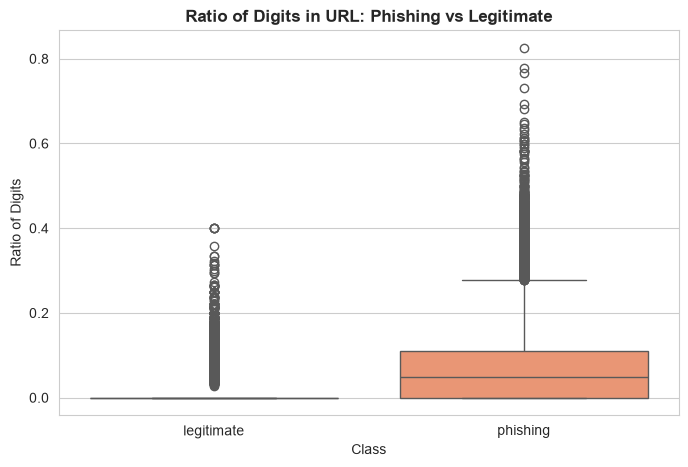

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='ratio_digits_url', palette='Set2')
plt.title('Ratio of Digits in URL: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Ratio of Digits', fontsize=10)
plt.show()

### Insight:
* The high digit ratio in phishing URLs indicates the use of raw IP addresses and randomized tokens, making this feature highly effective for accurate classification

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\3663292169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='num_subdomains', palette='Set2')


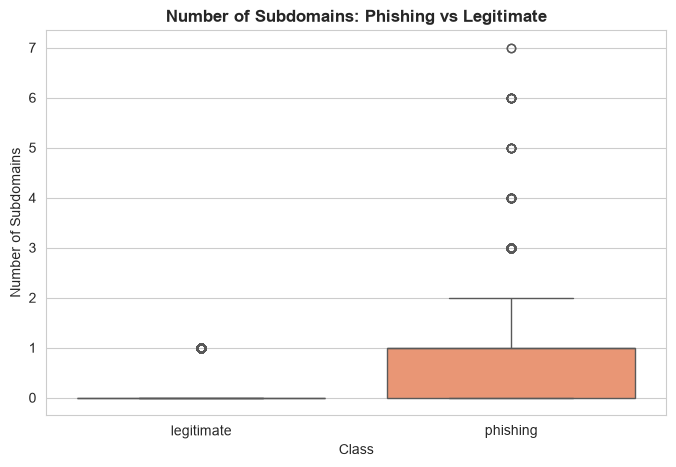

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='num_subdomains', palette='Set2')
plt.title('Number of Subdomains: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Number of Subdomains', fontsize=10)
plt.show()

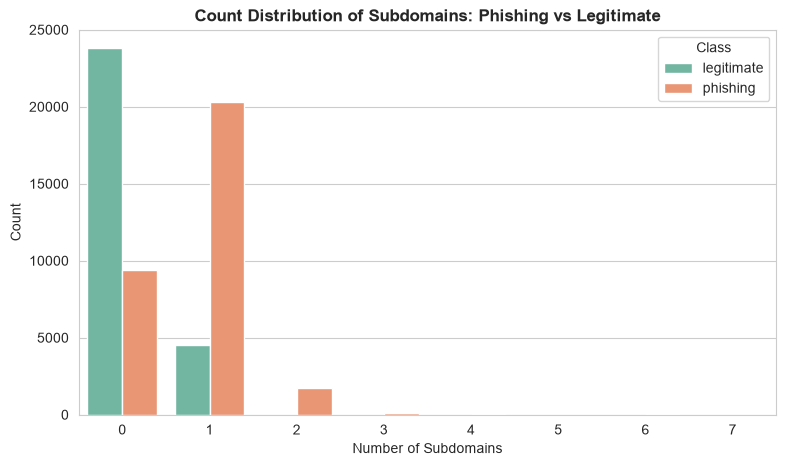

In [42]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='num_subdomains', hue='label', palette='Set2')
plt.title('Count Distribution of Subdomains: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Number of Subdomains', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

### Insight:
* Phishing websites frequently use higher numbers of subdomains to spoof legitimate domains and deceive users, providing a strong discriminative feature for classification.

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\2995582348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='length_hostname', palette='Set2')


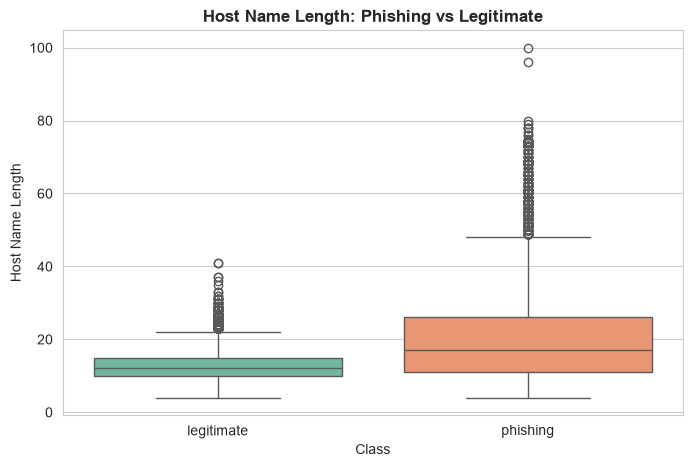

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='length_hostname', palette='Set2')
plt.title('Host Name Length: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=10)
plt.ylabel('Host Name Length', fontsize=10)
plt.show()

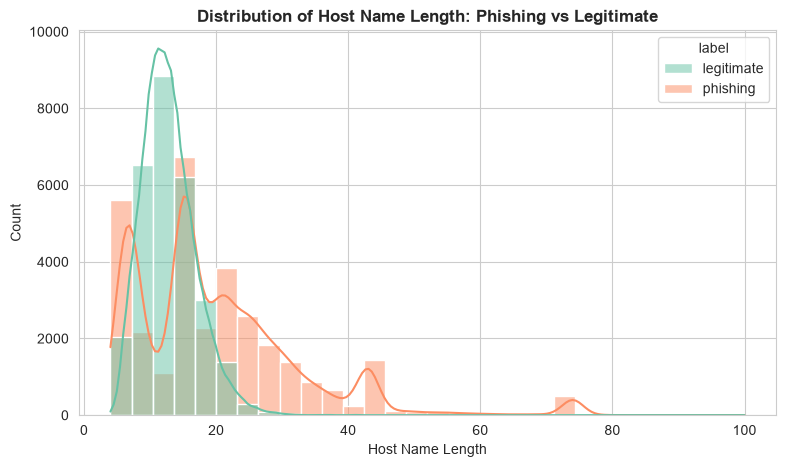

In [45]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='length_hostname', hue='label', kde=True, palette='Set2', bins=30)
plt.title('Distribution of Host Name Length: Phishing vs Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Host Name Length', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.show()

### Insight:
* ​Legitimate websites maintain concise and tightly distributed hostnames (mostly under 20 characters), reflecting standardized domain naming conventions.
* ​Phishing URLs exhibit significantly wider distributions and longer hostnames, often employing extended or obfuscated subdomain/domain structures to deceive users. This makes length_hostname a strong discriminative feature for machine learning models.

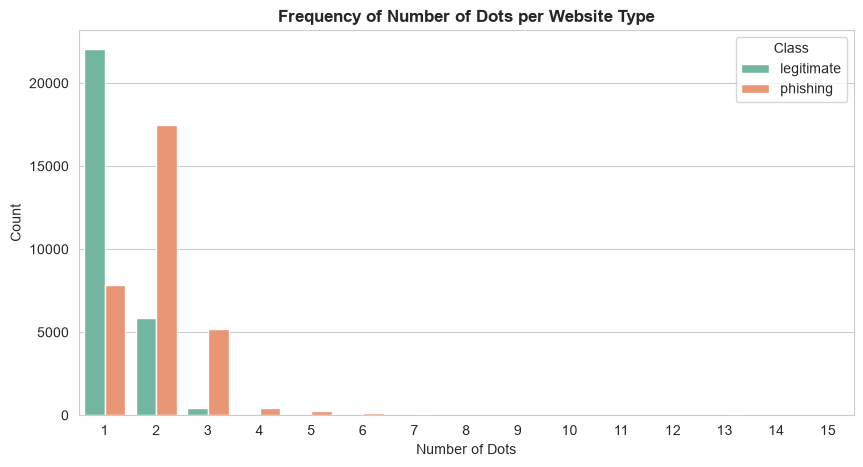

In [50]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['num_dots'] <= 15], x='num_dots', hue='label', palette='Set2')
plt.title('Frequency of Number of Dots per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Number of Dots', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

**Insight:**
* Legitimate websites heavily concentrate on having fewer dots (typically 1 dot), representing clean and direct domain structures.
* Phishing websites frequently show an increased number of dots (2 or more), often due to deceptive subdomains used by attackers to mimic legitimate URLs.
* This makes the number of dots a strong distinguishing feature for our classification model.


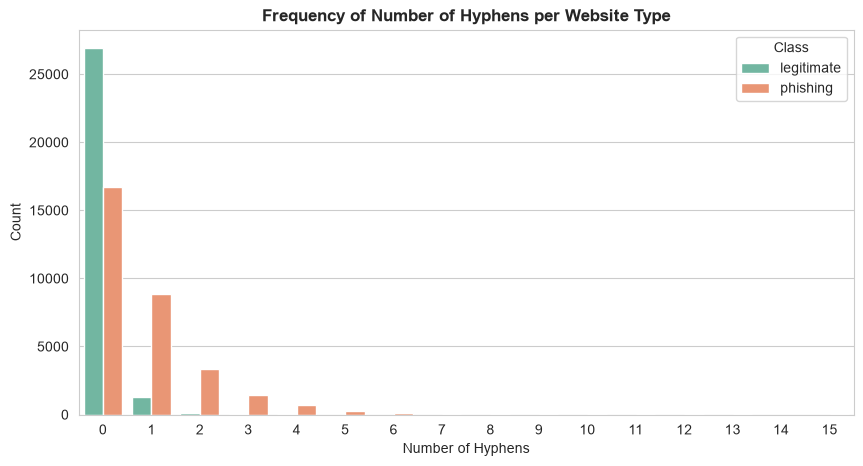

In [51]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['num_hyphens'] <= 15], x='num_hyphens', hue='label', palette='Set2')
plt.title('Frequency of Number of Hyphens per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Number of Hyphens', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

**Insight:**
* Legitimate websites heavily concentrate on having **zero hyphens** (0), indicating clean and straightforward domain names without extra separators.
* Phishing websites show a significantly higher frequency of containing **one or more hyphens** (1, 2, or more), as attackers often use hyphens in deceptive domain structures or subdomains to mimic trusted brands.
* This makes the number of hyphens another powerful feature for distinguishing malicious URLs from safe ones.


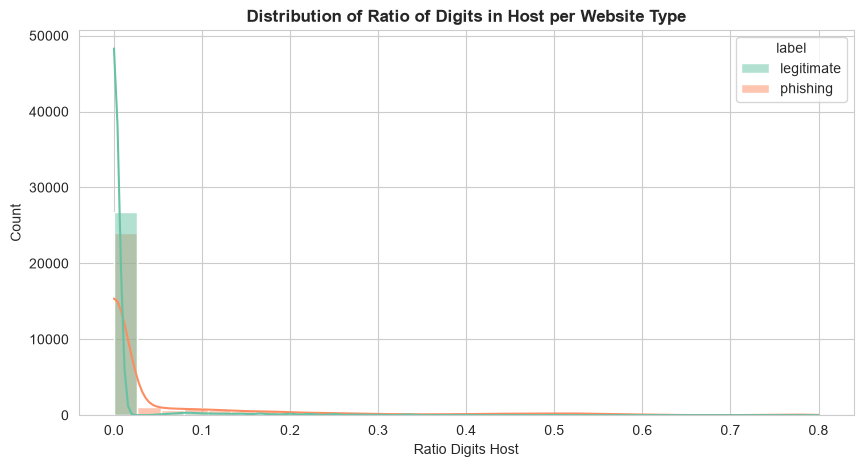

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='ratio_digits_host', hue='label', bins=30, kde=True, common_norm=False, palette='Set2', alpha=0.5)
plt.title('Distribution of Ratio of Digits in Host per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Ratio Digits Host', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.show()

**Insight:**
* Both legitimate and phishing websites heavily cluster around a zero digit ratio in the host, meaning most URLs do not use numbers in their domain names.
* However, phishing URLs exhibit a noticeable tail extending toward higher digit ratios, indicating that attackers occasionally introduce numbers to mimic legitimate domains or create confusing subdomains.
* This feature contributes as a useful indicator for detecting anomalies in URL structures.


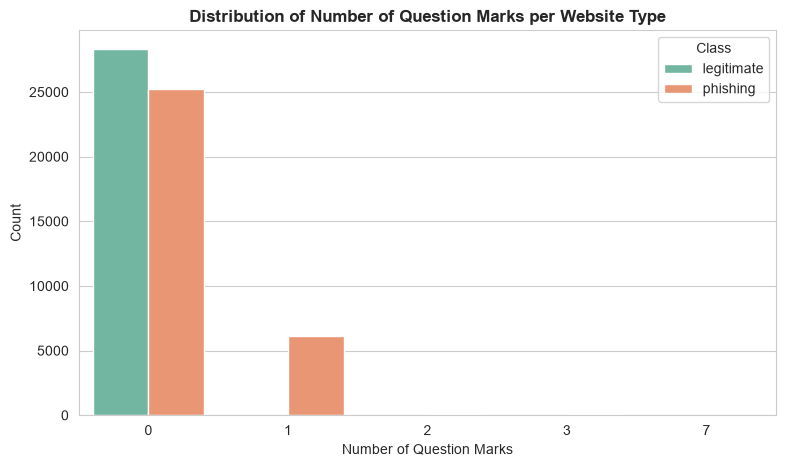

In [56]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='num_question_mark', hue='label', palette='Set2')
plt.title('Distribution of Number of Question Marks per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Number of Question Marks', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

**Insight & Discussion:**
* For URLs with zero question marks (0), both legitimate and phishing websites appear in large numbers.
* However, when the number of question marks is 1 or greater, **legitimate websites are completely absent**, leaving the space exclusively occupied by phishing URLs.
* This makes `num_question_mark` a powerful and deterministic behavioral indicator for the classifier, as query parameters (signified by '?') are heavily exploited by attackers to craft malicious redirection links.


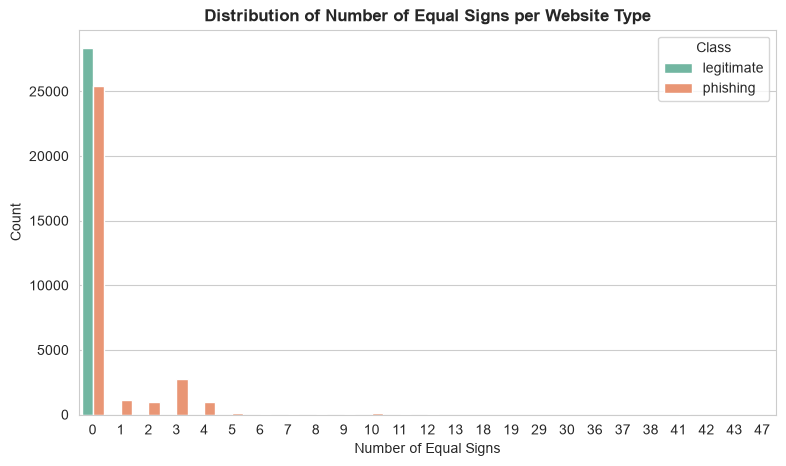

In [57]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='num_eq', hue='label', palette='Set2')
plt.title('Distribution of Number of Equal Signs per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Number of Equal Signs', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

**Insight & Discussion:**
* When the number of equal signs (`=`) is 0, both legitimate and phishing websites coexist.
* However, for values greater than or equal to 1, phishing websites strongly dominate, while legitimate websites drop to negligible counts.
* This indicates that query parameters and key-value pairs (represented by '=') are heavily utilized in malicious links to pass deceptive arguments, making it a strong feature for the classifier.


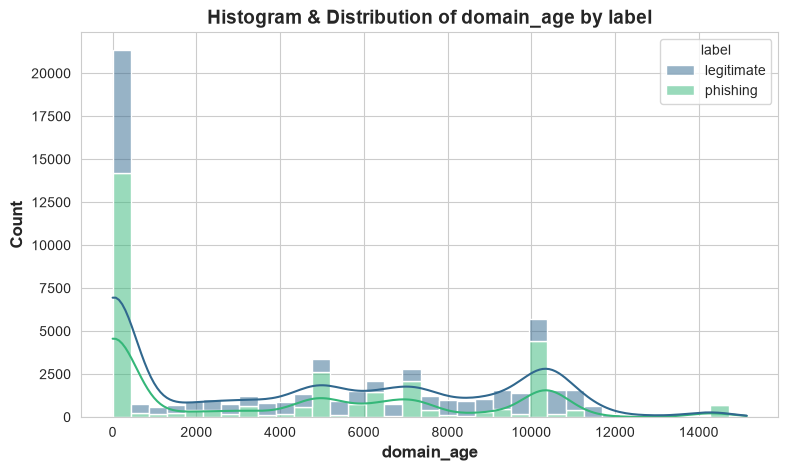

In [58]:
plot_histogram(df, column='domain_age', target='label')

C:\Users\MAKKA\AppData\Local\Temp\ipykernel_19936\703538857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='domain_age', palette='Set2')


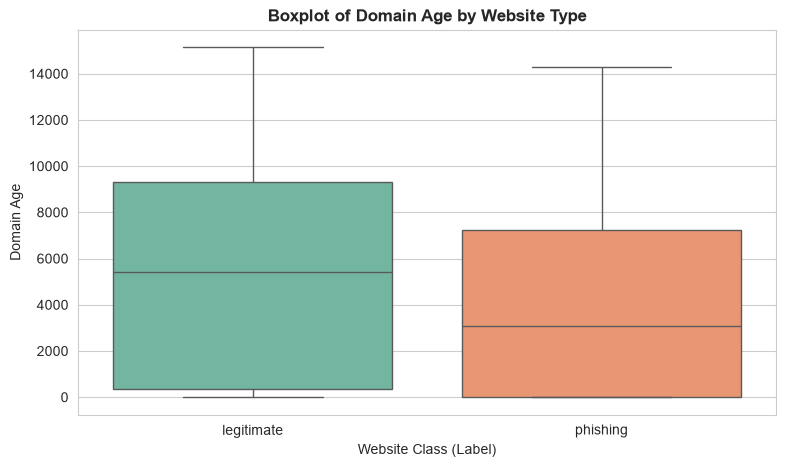

In [59]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='label', y='domain_age', palette='Set2')
plt.title('Boxplot of Domain Age by Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Website Class (Label)', fontsize=10)
plt.ylabel('Domain Age', fontsize=10)
plt.show()

**Insight & Discussion:**
* The distribution shows that legitimate websites generally have a higher domain age, with the median value resting significantly higher compared to phishing websites.
* Phishing websites heavily concentrate around lower domain ages (recently registered domains), as attackers frequently spin up new domains to bypass blocklists and security filters.
* This makes `domain_age` a critical behavioral feature for distinguishing established, trustworthy platforms from transient malicious sites.


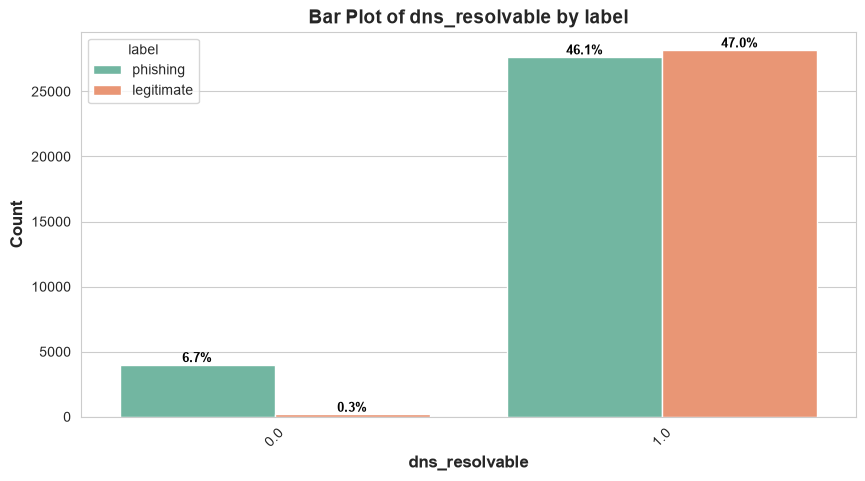

In [60]:
plot_barplot(df, column='dns_resolvable', target='label')

**Insight & Discussion:**
* The bar plot illustrates the resolvability status of DNS records for both classes.
* A vast majority of both legitimate and phishing websites successfully resolve via DNS (value 1.0), accounting for roughly 46-47% each.
* However, a noticeable portion of phishing websites (about 6.7%) fail DNS resolution (value 0.0), which typically corresponds to dead links, ephemeral malicious domains, or domains blocked and stripped of valid DNS records.
* This indicates that while DNS resolvability alone doesn't separate all classes, the presence of unresolvable domains heavily leans toward malicious activity.


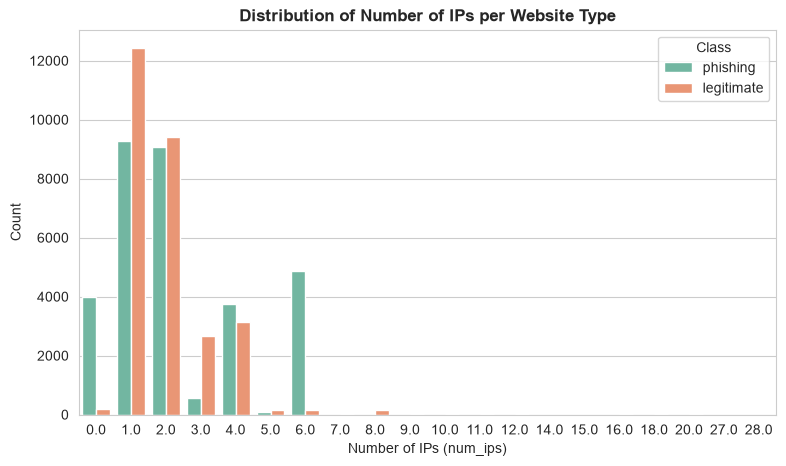

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='num_ips', hue='label', palette='Set2')
plt.title('Distribution of Number of IPs per Website Type', fontsize=12, fontweight='bold')
plt.xlabel('Number of IPs (num_ips)', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.legend(title='Class')
plt.show()

**Insight & Discussion:**
* The plot reveals clear structural differences in the number of associated IP addresses (`num_ips`) between legitimate and phishing websites.
* Legitimate websites heavily concentrate on standard lower counts (such as 1.0 and 2.0 IPs), typically reflecting stable hosting providers, direct servers, or standard Content Delivery Networks (CDNs).
* In contrast, phishing websites show significant representation at zero IPs (indicating unresolvable or dead targets) as well as unusual spikes at higher IP counts (e.g., 6.0 IPs), which often correspond to fast-flux hosting techniques used by attackers to evade takedowns.
* This behavioral pattern establishes `num_ips` as a strong indicator for identifying infrastructure anomalies associated with malicious sites.


<div style="
    background-color: #1e1e2f;
    color: #6164ff;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 16px;
    font-weight: bold;
">
    Bivariate & Multivariate Analysis
</div>

In [86]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,url,str,"[https://manua.ls, https://t.co/r77VHQx9lP, ht...",60000,0,0.000000,0
1,entropy,float64,"[3.939470994001288, 4.152391277629867, 4.05595...",14054,0,0.000000,0
2,url_length,int64,"[22, 21, 23, 20, 19, 18, 17, 24, 175, 16]",454,0,0.000000,0
3,num_www,int64,"[0, 1, 2, 3]",4,0,0.000000,0
4,ratio_digits_url,float64,"[0.0, 0.0454545454545454, 0.0909090909090909, ...",2081,0,0.000000,0
5,num_subdomains,int64,"[0, 1, 2, 3, 4, 6, 5, 7]",8,0,0.000000,0
6,length_hostname,int64,"[15, 6, 11, 12, 7, 13, 10, 8, 14, 16]",79,0,0.000000,0
7,random_domain,int64,"[0, 1]",2,0,0.000000,0
8,num_dots,int64,"[1, 2, 3, 4, 5, 6, 13, 7, 10, 8]",18,0,0.000000,0
9,num_hyphens,int64,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10]",28,0,0.000000,0


In [90]:

import tldextract
def registrable_domain(u):
    ext = tldextract.extract(u)
    return ".".join(p for p in [ext.domain, ext.suffix] if p)

df["reg_domain"] = df["url"].apply(registrable_domain)

dom_label_nunique = df.groupby("reg_domain")["label"].nunique()
conflict_domains = dom_label_nunique[dom_label_nunique > 1].index
print(f"Registrable domains carrying BOTH labels: {len(conflict_domains)}")

df[df["reg_domain"].isin(conflict_domains)].sort_values("reg_domain")[
    ["url", "reg_domain", "label"]
].head(12)

Registrable domains carrying BOTH labels: 187


,url,reg_domain,label
7388,https://form.123formbuilder.com/6236576/para-s...,123formbuilder.com,phishing
21136,https://form.123formbuilder.com/5671470,123formbuilder.com,phishing
3952,https://form.123formbuilder.com/6613699/brunob...,123formbuilder.com,phishing
18865,https://123formbuilder.com,123formbuilder.com,legitimate
40207,https://rayjanikowski7157914.activehosted.com/...,activehosted.com,phishing
58193,https://activehosted.com,activehosted.com,legitimate
14105,https://dk118633.activehosted.com/f/1,activehosted.com,phishing
34888,https://dwad8097.activehosted.com/f/2,activehosted.com,phishing
33736,https://dk11863393405.activehosted.com/f/1,activehosted.com,phishing
11088,https://drewf73669266.activehosted.com/f/1,activehosted.com,phishing


Unique registrable domains: 30031 / rows: 60000
reg_domain
google.com              4717
weebly.com              1874
qrco.de                 1619
bit.ly                  1485
firebaseapp.com         1356
web.app                 1326
q-r.to                  1310
r2.dev                  1267
ead.me                  1240
adobe.com                728
dweb.link                492
pages.dev                489
campaign-archive.com     451
wixsite.com              390
dropbox.com              379
Name: count, dtype: int64


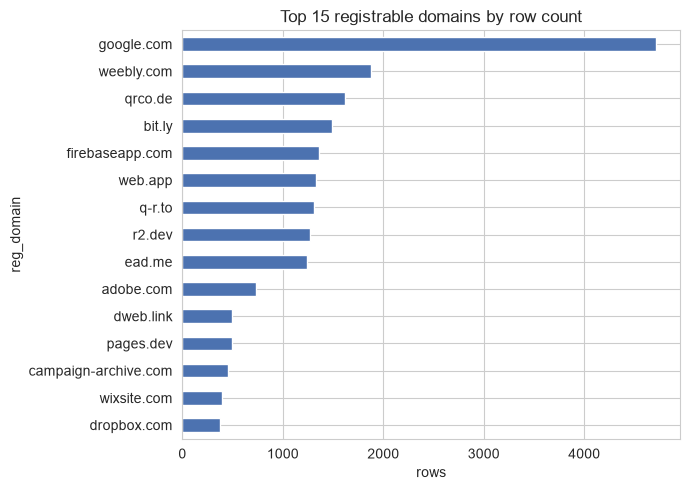

In [91]:

print("Unique registrable domains:", df['reg_domain'].nunique(), "/ rows:", len(df))
top_domains = df["reg_domain"].value_counts().head(15)
print(top_domains)

fig, ax = plt.subplots(figsize=(7, 5))
top_domains.sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Top 15 registrable domains by row count")
ax.set_xlabel("rows")
plt.tight_layout()
plt.show()

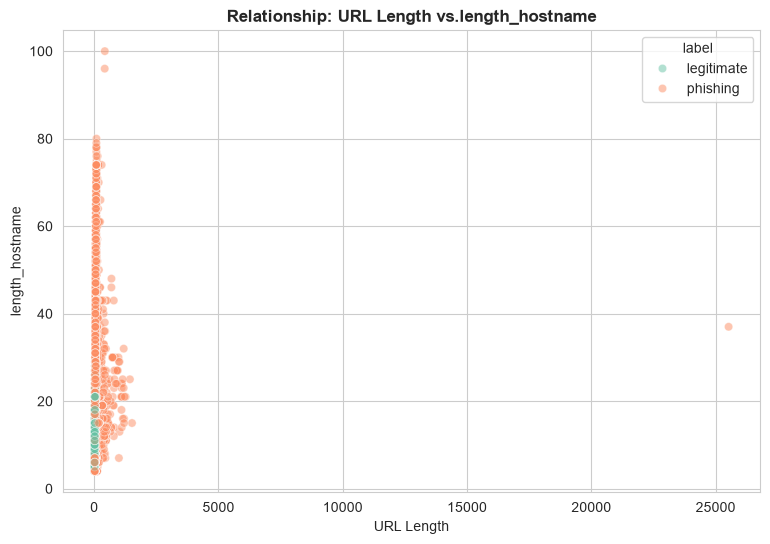

In [84]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='url_length', y='length_hostname', hue='label', alpha=0.5, palette='Set2')
plt.title('Relationship: URL Length vs.length_hostname', fontsize=12, fontweight='bold')
plt.xlabel('URL Length')
plt.ylabel('length_hostname')
plt.show()

**Insight:**
* **Deceptive URL Lengths:** Phishing websites frequently use excessively long URLs to hide the true domain and trick users.
* **Data Cleaning Necessity:** The scatter plot highlights extreme outliers (URLs over thousands of characters), indicating that data cleaning and filtering are required before model training to ensure high accuracy.


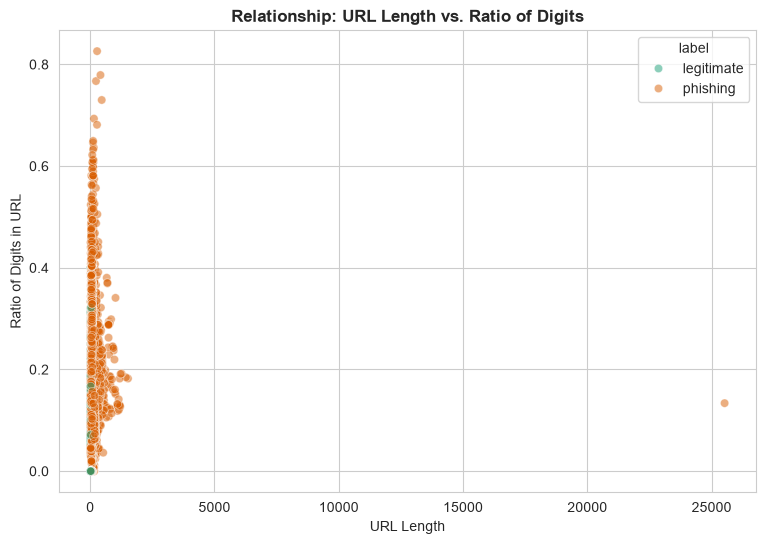

In [71]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='url_length', y='ratio_digits_url', hue='label', alpha=0.5, palette='Dark2')
plt.title('Relationship: URL Length vs. Ratio of Digits', fontsize=12, fontweight='bold')
plt.xlabel('URL Length')
plt.ylabel('Ratio of Digits in URL')
plt.show()

**Insight:**
* **Higher Digit Concentration:** Phishing URLs (orange dots) show a more distributed and noticeable ratio of numeric digits even at shorter lengths, which hackers use to obfuscate the real web address.
* **Feature Separation:** The plot demonstrates that combining URL length with digit ratios provides a clear behavioral pattern to help machine learning models distinguish malicious links from legitimate ones.


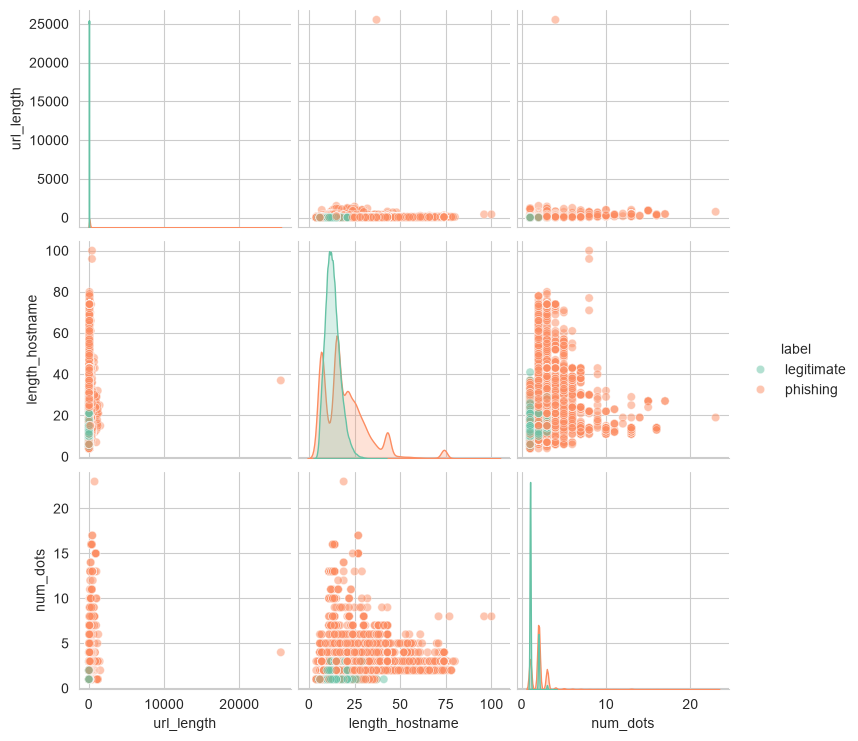

In [77]:
cols_to_plot = ['url_length', 'length_hostname', 'num_dots', 'label']
sns.pairplot(df[cols_to_plot], hue='label', palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

**Key Insight:**
* **Behavioral Pattern:** Phishing URLs exhibit a joint scaling pattern where length, hostname length, and the number of dots increase simultaneously, contrasting with the compact and structured nature of legitimate URLs.
* **Feature Synergy:** This confirms that combining these features provides complementary signals, enabling machine learning models to classify malicious links with higher accuracy and confidence.


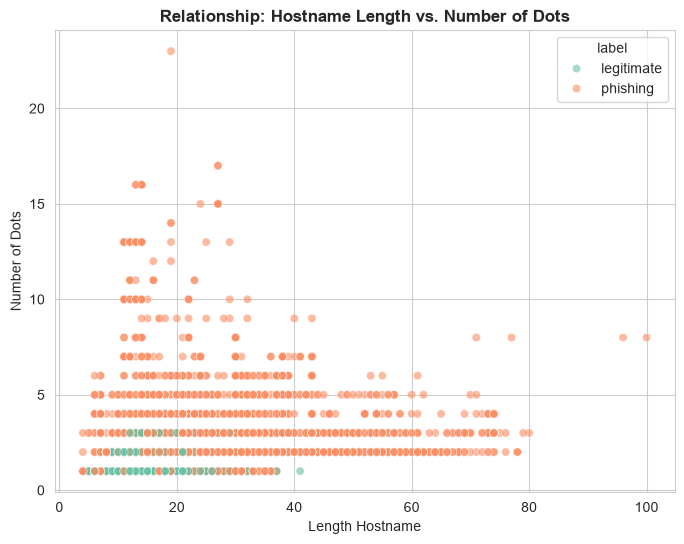

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='length_hostname', y='num_dots', hue='label', palette='Set2', alpha=0.6)
plt.title('Relationship: Hostname Length vs. Number of Dots', fontsize=12, fontweight='bold')
plt.xlabel('Length Hostname')
plt.ylabel('Number of Dots')
plt.show()

**Insight:**
* **Subdomain Obfuscation Pattern:** Phishing URLs (orange dots) show a high concentration of multiple dots as the hostname length increases, which malicious actors use to create deceptive subdomains.
* **Separation Threshold:** The distribution clearly separates malicious behavior from legitimate sites, proving that hostname length combined with dot count is a highly effective indicator for machine learning classification.


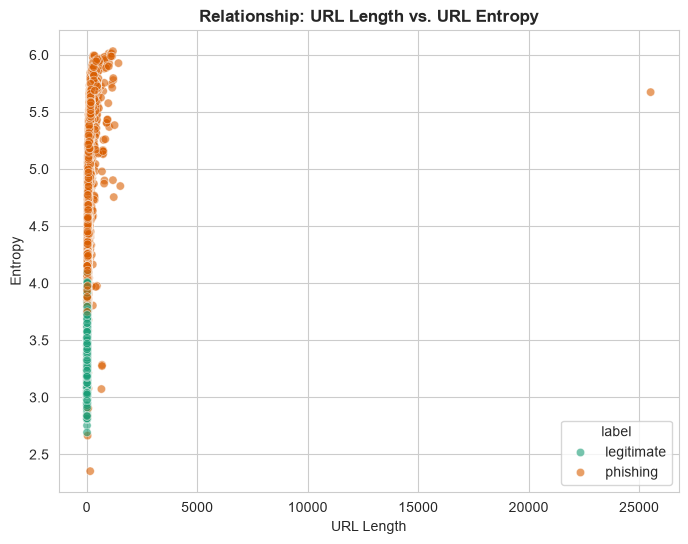

In [79]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='url_length', y='entropy', hue='label', palette='Dark2', alpha=0.6)
plt.title('Relationship: URL Length vs. URL Entropy', fontsize=12, fontweight='bold')
plt.xlabel('URL Length')
plt.ylabel('Entropy')
plt.show()

**Insight:**
* **High Entropy Anomaly:** Phishing URLs (orange dots) exhibit significantly higher entropy values (reaching above 5.5) even at shorter lengths, indicating the use of randomized strings, obfuscation, or encoded parameters.
* **Discriminative Power:** Entropy serves as a strong standalone indicator, allowing machine learning models to effectively separate sophisticated phishing attempts from clean, structured legitimate URLs.


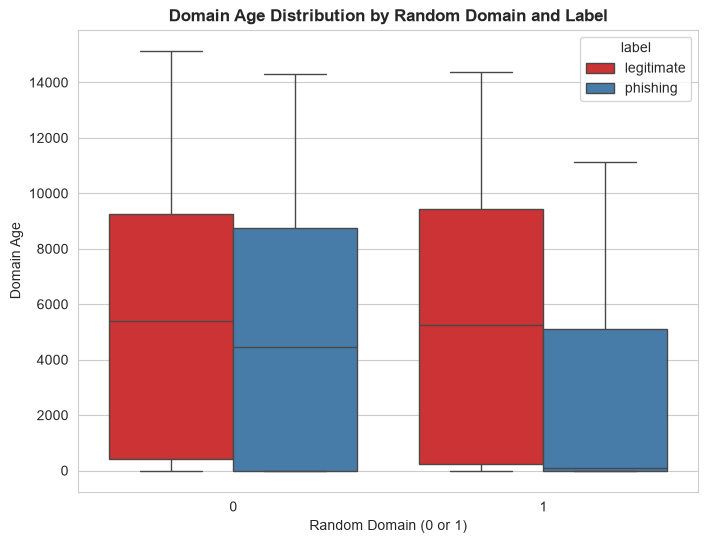

In [80]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='random_domain', y='domain_age', hue='label', palette='Set1')
plt.title('Domain Age Distribution by Random Domain and Label', fontsize=12, fontweight='bold')
plt.xlabel('Random Domain (0 or 1)')
plt.ylabel('Domain Age')
plt.show()

**Insight:**
* **Domain Age Disparity:** Legitimate domains (red) generally exhibit higher and more stable age distributions, whereas phishing domains (blue) tend to span wider variations or include newer registrations often deployed temporarily by attackers.
* **Predictive Value:** Domain age combined with random domain indicators provides a vital longevity signal, helping the machine learning model distinguish between established trusted entities and newly spun-up malicious sites.


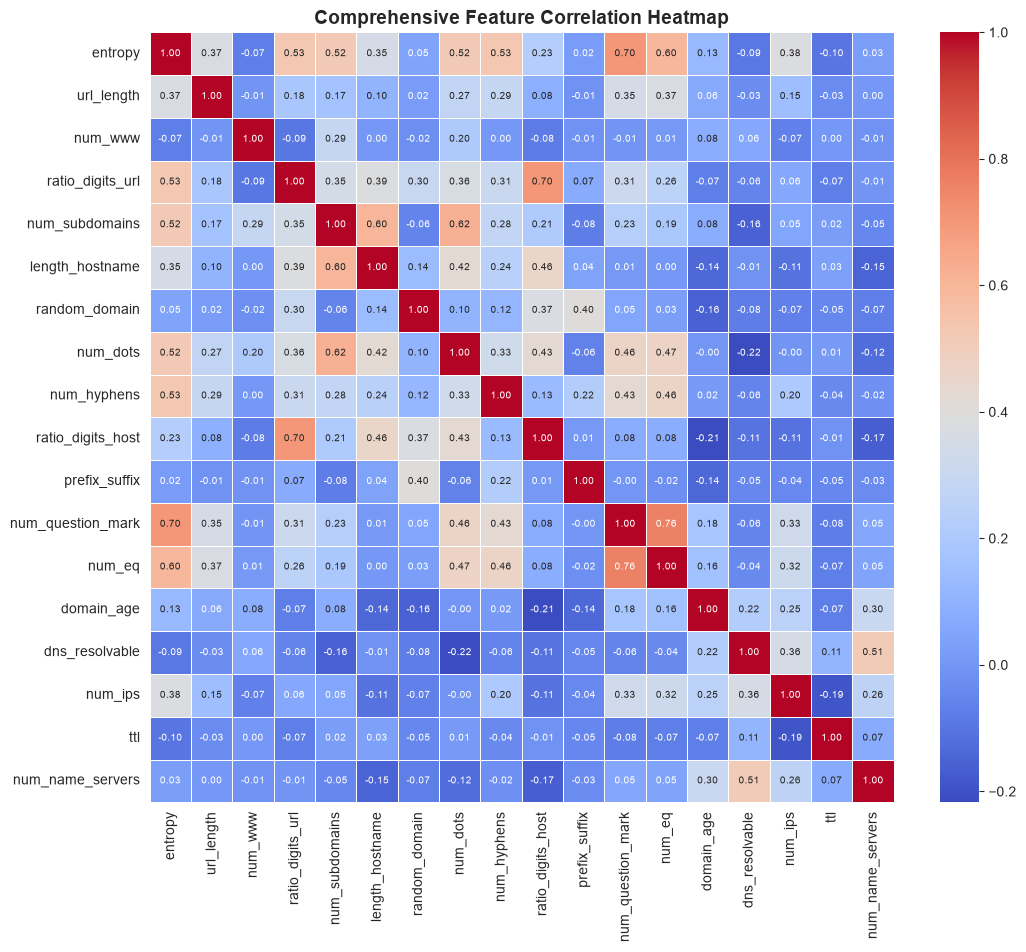

In [82]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={"size": 7})
plt.title('Comprehensive Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()